In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('D:\sara\Quera_AI_Engineer\Quera Project_1\Quera-Project-1\data\Divar.csv')
# test = pd.read_csv('test.csv')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14796\3603220263.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('D:\sara\Quera_AI_Engineer\Quera Project_1\Quera-Project-1\data\Divar.csv')


In [3]:
train.head(5)

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  object 
 2   cat3_slug                   999999 non-null   object 
 3   city_slug                   999998 non-null   object 
 4   neighborhood_slug           437139 non-null   object 
 5   created_at_month            1000000 non-null  object 
 6   user_type                   288882 non-null   object 
 7   description                 1000000 non-null  object 
 8   title                       999946 non-null   object 
 9   rent_mode                   352994 non-null   object 
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   object 
 13

<h1>Descriptive statistics</h1>

<hr>

<h3>Q 2:</h3>

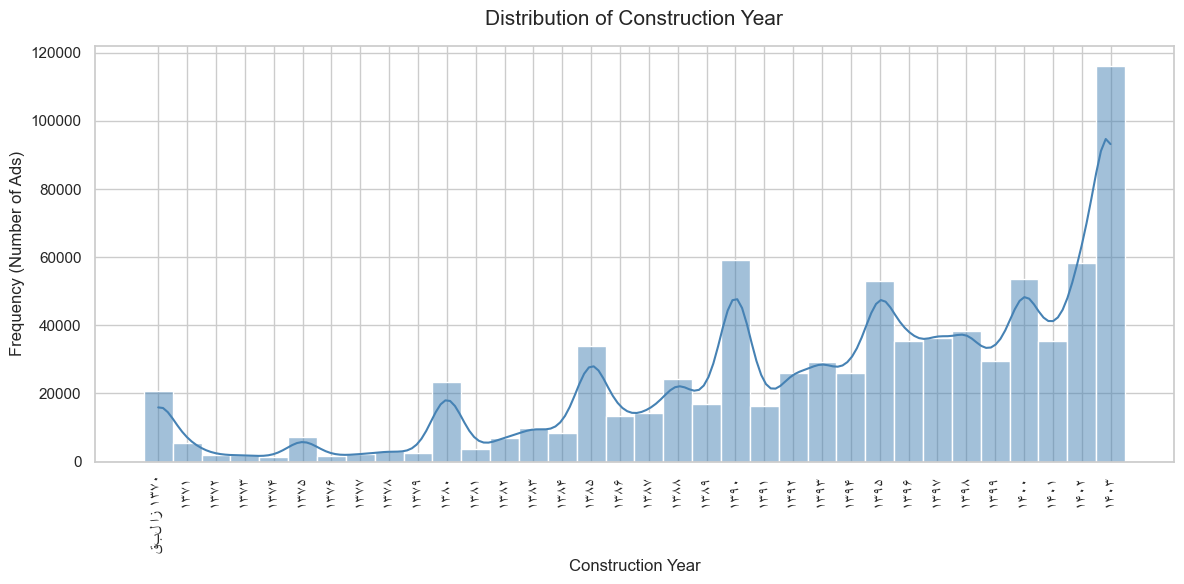

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Section 0: Sorting Data
# ==========================================
# Sort the DataFrame by construction year
train = train.sort_values(by='construction_year')

# ==========================================
# Section 1: General Configuration
# ==========================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# ==========================================
# Section 2: Plotting Histogram
# ==========================================
sns.histplot(
    data=train,
    x='construction_year',
    bins=30,
    kde=True,
    color='steelblue'
)

# ==========================================
# Section 3: Titles, Labels, and Ticks
# ==========================================
plt.title('Distribution of Construction Year', fontsize=15, pad=15)
plt.xlabel('Construction Year', fontsize=12)
plt.ylabel('Frequency (Number of Ads)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# ==========================================
# Section 4: Render and Display
# ==========================================
plt.tight_layout()
plt.show()


<h3>Q 5:</h3>

In [8]:
pip install folium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import folium
from folium.plugins import HeatMap
import pandas as pd


df_location = train.dropna(subset=['location_latitude', 'location_longitude'])


df_sample = df_location.sample(n=20000, random_state=42)


map_center = [df_sample['location_latitude'].mean(), df_sample['location_longitude'].mean()]


m = folium.Map(location=map_center, zoom_start=11, tiles='CartoDB Positron')


heat_data = df_sample[['location_latitude', 'location_longitude']].values.tolist()


HeatMap(heat_data, radius=15, blur=10, max_zoom=1).add_to(m)


m.save('divar_heatmap.html')


m


In [ ]:

top_districts = train['neighborhood_slug'].value_counts().head(5)
print(top_districts)


elahiyehblvd    7076
poonak          5393
ghasemabad      5216
saadat-abad     4686
bolvartoos      4684
Name: neighborhood_slug, dtype: int64


In [ ]:

top_districts = train[['city_slug', 'neighborhood_slug']].value_counts().reset_index(name='ad_count')


print(top_districts.head(10))

  city_slug neighborhood_slug  ad_count
0   mashhad      elahiyehblvd      7076
1    tehran            poonak      5393
2   mashhad        ghasemabad      5216
3    tehran       saadat-abad      4686
4   mashhad        bolvartoos      4684
5     karaj        gohardasht      3738
6    tehran   west-tehranpars      3575
7    tehran      chitgar-lake      3562
8       qom     pardisan-ghom      3472
9    tehran           jeyhoun      3189
